<a href="https://colab.research.google.com/github/microsoft/autogen/blob/main/notebook/agentchat_groupchat_vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Auto Generated Agent Chat: Group Chat with Coder and Visualization Critic

AutoGen offers conversable agents powered by LLM, tool or human, which can be used to perform tasks collectively via automated chat. This framework allows tool use and human participation through multi-agent conversation.
Please find documentation about this feature [here](https://microsoft.github.io/autogen/docs/Use-Cases/agent_chat).

## Requirements

AutoGen requires `Python>=3.8`. To run this notebook example, please install:
```bash
pip install pyautogen
```

In [1]:
pip install "pyautogen>=0.2.3"

Note: you may need to restart the kernel to use updated packages.


## Set your API Endpoint

The [`config_list_from_json`](https://microsoft.github.io/autogen/docs/reference/oai/openai_utils#config_list_from_json) function loads a list of configurations from an environment variable or a json file.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image

import autogen

config_list_gpt4 = autogen.config_list_from_json(
    "OAI_CONFIG_LIST",
    filter_dict={
        "model": ["gpt-4"],
    },
)
# config_list_gpt35 = autogen.config_list_from_json(
#     "OAI_CONFIG_LIST",
#     filter_dict={
#         "model": {
#             "gpt-3.5-turbo",
#             "gpt-3.5-turbo-16k",
#             "gpt-3.5-turbo-0301",
#             "chatgpt-35-turbo-0301",
#             "gpt-35-turbo-v0301",
#         },
#     },
# )

It first looks for environment variable "OAI_CONFIG_LIST" which needs to be a valid json string. If that variable is not found, it then looks for a json file named "OAI_CONFIG_LIST". It filters the configs by models (you can filter by other keys as well). Only the gpt-4 models are kept in the list based on the filter condition.

The config list looks like the following:
```python
config_list = [
    {
        'model': 'gpt-4',
        'api_key': '<your OpenAI API key here>',
    },
    {
        'model': 'gpt-4',
        'api_key': '<your Azure OpenAI API key here>',
        'base_url': '<your Azure OpenAI API base here>',
        'api_type': 'azure',
        'api_version': '2023-08-01-preview',
    },
    {
        'model': 'gpt-4-32k',
        'api_key': '<your Azure OpenAI API key here>',
        'base_url': '<your Azure OpenAI API base here>',
        'api_type': 'azure',
        'api_version': '2023-08-01-preview',
    },
]
```

You can set the value of config_list in any way you prefer. Please refer to this [notebook](https://github.com/microsoft/autogen/blob/main/website/docs/llm_endpoint_configuration.ipynb) for full code examples of the different methods.

## Construct Agents

<div style="margin: 0 auto; width: 500px">
    <img src="viz_gc.png" alt="Drawing"/>
  </div>

In [3]:
llm_config = {"config_list": config_list_gpt4, "cache_seed": 42}
user_proxy = autogen.UserProxyAgent(
    name="User_proxy",
    system_message="A human admin.",
    code_execution_config={
        "last_n_messages": 3,
        "work_dir": "groupchat",
        "use_docker": False,
    },  # Please set use_docker=True if docker is available to run the generated code. Using docker is safer than running the generated code directly.
    human_input_mode="NEVER",
)
coder = autogen.AssistantAgent(
    name="Coder",  # the default assistant agent is capable of solving problems with code
    llm_config=llm_config,
)
critic = autogen.AssistantAgent(
    name="Critic",
    system_message="""Critic. You are a helpful assistant highly skilled in evaluating the quality of a given visualization code by providing a score from 1 (bad) - 10 (good) while providing clear rationale. YOU MUST CONSIDER VISUALIZATION BEST PRACTICES for each evaluation. Specifically, you can carefully evaluate the code across the following dimensions
- bugs (bugs):  are there bugs, logic errors, syntax error or typos? Are there any reasons why the code may fail to compile? How should it be fixed? If ANY bug exists, the bug score MUST be less than 5.
- Data transformation (transformation): Is the data transformed appropriately for the visualization type? E.g., is the dataset appropriated filtered, aggregated, or grouped  if needed? If a date field is used, is the date field first converted to a date object etc?
- Goal compliance (compliance): how well the code meets the specified visualization goals?
- Visualization type (type): CONSIDERING BEST PRACTICES, is the visualization type appropriate for the data and intent? Is there a visualization type that would be more effective in conveying insights? If a different visualization type is more appropriate, the score MUST BE LESS THAN 5.
- Data encoding (encoding): Is the data encoded appropriately for the visualization type?
- aesthetics (aesthetics): Are the aesthetics of the visualization appropriate for the visualization type and the data?

YOU MUST PROVIDE A SCORE for each of the above dimensions.
{bugs: 0, transformation: 0, compliance: 0, type: 0, encoding: 0, aesthetics: 0}
Do not suggest code.
Finally, based on the critique above, suggest a concrete list of actions that the coder should take to improve the code.
""",
    llm_config=llm_config,
)

groupchat = autogen.GroupChat(agents=[user_proxy, coder, critic], messages=[], max_round=20)
manager = autogen.GroupChatManager(groupchat=groupchat, llm_config=llm_config)

## Start Chat

In [4]:
user_proxy.initiate_chat(
    manager,
    message="download data from https://raw.githubusercontent.com/uwdata/draco/master/data/cars.csv and plot a visualization that tells us about the relationship between weight and horsepower. Save the plot to a file. Print the fields in a dataset before visualizing it.",
)
# type exit to terminate the chat

User_proxy (to chat_manager):

download data from https://raw.githubusercontent.com/uwdata/draco/master/data/cars.csv and plot a visualization that tells us about the relationship between weight and horsepower. Save the plot to a file. Print the fields in a dataset before visualizing it.

--------------------------------------------------------------------------------
Coder (to chat_manager):

We can use the pandas library in Python to read our CSV dataset and matplotlib for plotting.

The first step is to download the data using pandas' `read_csv()` function and inspect the fields. Let's do it.

```python
import pandas as pd

# URL of the dataset
url = 'https://raw.githubusercontent.com/uwdata/draco/master/data/cars.csv'

# Download the dataset
df = pd.read_csv(url)

# Print the fields in the dataset
print(df.columns.tolist())
```

Once you've executed this code block, it should return a list of column names in the downloaded dataset. After we know the exact title casing of 'weight' a

/home/jason/dl_env/lib/python3.10/site-packages/autogen/agentchat/conversable_agent.py:838: UserWarning: No summary_method provided or summary_method is not supported: 
  warnings.warn("No summary_method provided or summary_method is not supported: ")


ChatResult(chat_history=[{'content': 'download data from https://raw.githubusercontent.com/uwdata/draco/master/data/cars.csv and plot a visualization that tells us about the relationship between weight and horsepower. Save the plot to a file. Print the fields in a dataset before visualizing it.', 'role': 'assistant'}, {'content': "We can use the pandas library in Python to read our CSV dataset and matplotlib for plotting.\n\nThe first step is to download the data using pandas' `read_csv()` function and inspect the fields. Let's do it.\n\n```python\nimport pandas as pd\n\n# URL of the dataset\nurl = 'https://raw.githubusercontent.com/uwdata/draco/master/data/cars.csv'\n\n# Download the dataset\ndf = pd.read_csv(url)\n\n# Print the fields in the dataset\nprint(df.columns.tolist())\n```\n\nOnce you've executed this code block, it should return a list of column names in the downloaded dataset. After we know the exact title casing of 'weight' and 'horsepower' fields we can use matplotlib to

## Display the saved figure

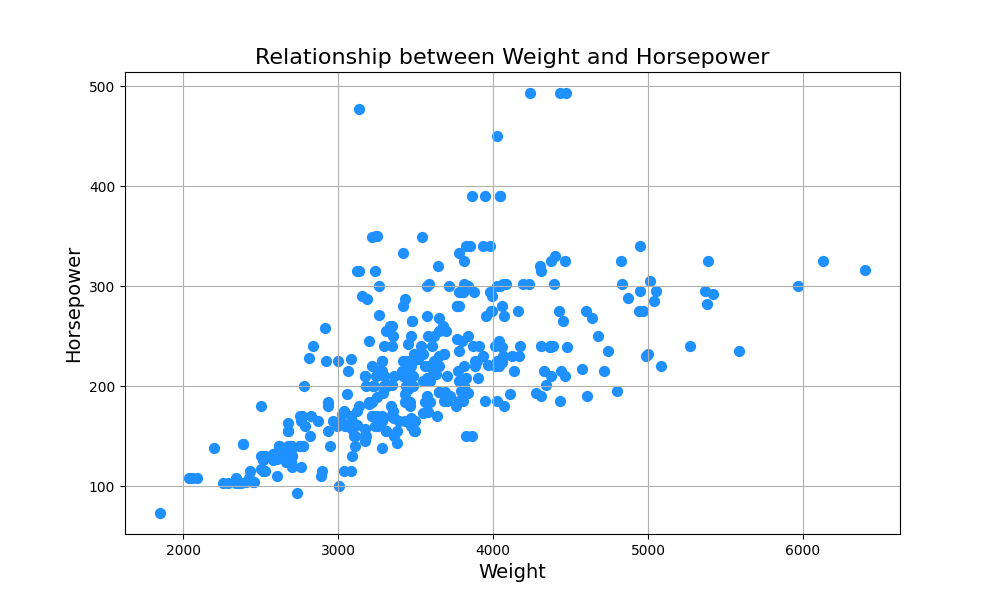

In [5]:
Image(filename="groupchat/weight_vs_horsepower.png")

## Example 2

In [6]:
user_proxy.reset()
coder.reset()
critic.reset()
groupchat = autogen.GroupChat(agents=[user_proxy, coder, critic], messages=[], max_round=20)
manager = autogen.GroupChatManager(groupchat=groupchat, llm_config=llm_config)
user_proxy.initiate_chat(
    manager,
    message="download data from https://raw.githubusercontent.com/vega/vega/main/docs/data/seattle-weather.csv and show me a plot that tells me about the amount of each weather . Save the plot to a file. Print the fields in a dataset before visualizing it. Take the feedback from the critic to improve the code.",
)

User_proxy (to chat_manager):

download data from https://raw.githubusercontent.com/vega/vega/main/docs/data/seattle-weather.csv and show me a plot that tells me about the amount of each weather . Save the plot to a file. Print the fields in a dataset before visualizing it. Take the feedback from the critic to improve the code.

--------------------------------------------------------------------------------
Coder (to chat_manager):

Firstly, I will write a script to download the data from the provided URL and then read the content of this CSV file to determine the fields in the dataset. 

After inspecting the fields, I will prepare the code for generating the plot. We will use the Pandas library to handle the CSV file, and Matplotlib to create the plot. The plot will be saved to a file as well.

Here is the Python code:

```python
# filename: download_and_visualize_data.py

import pandas as pd
import matplotlib.pyplot as plt

# Download and read the data
data_url = 'https://raw.github

ChatResult(chat_history=[{'content': 'download data from https://raw.githubusercontent.com/vega/vega/main/docs/data/seattle-weather.csv and show me a plot that tells me about the amount of each weather . Save the plot to a file. Print the fields in a dataset before visualizing it. Take the feedback from the critic to improve the code.', 'role': 'assistant'}, {'content': 'Firstly, I will write a script to download the data from the provided URL and then read the content of this CSV file to determine the fields in the dataset. \n\nAfter inspecting the fields, I will prepare the code for generating the plot. We will use the Pandas library to handle the CSV file, and Matplotlib to create the plot. The plot will be saved to a file as well.\n\nHere is the Python code:\n\n```python\n# filename: download_and_visualize_data.py\n\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\n# Download and read the data\ndata_url = \'https://raw.githubusercontent.com/vega/vega/main/docs/data/seattle-w

### The original chart before critic's suggestion

Fields in the dataset:
Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')
Plot has been saved to 'weather_plot.png'.


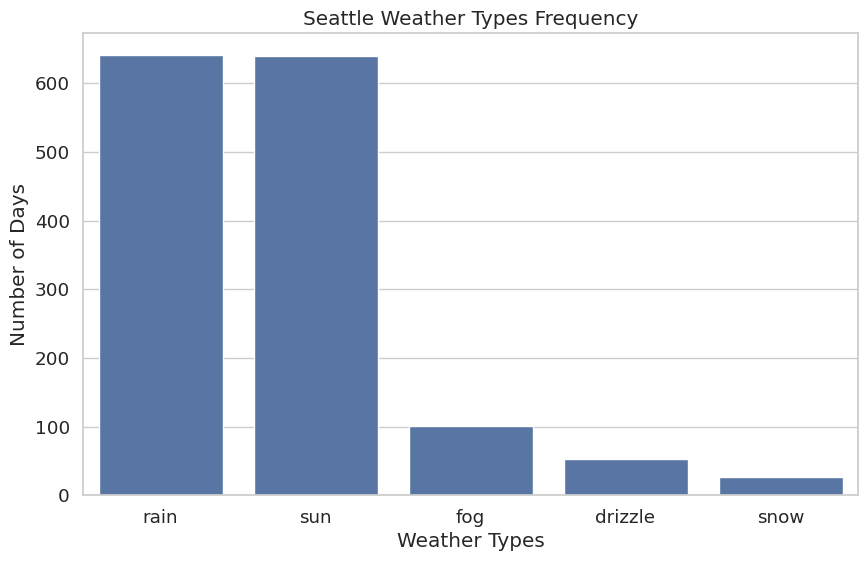

In [7]:
url = "https://raw.githubusercontent.com/vega/vega/main/docs/data/seattle-weather.csv"
data = pd.read_csv(url)
print("Fields in the dataset:")
print(data.columns)

# Count the occurrences of each weather type
weather_counts = data["weather"].value_counts()

# Create a bar plot of weather occurrences
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(10, 6))
weather_plot = sns.barplot(x=weather_counts.index, y=weather_counts.values)

# Add labels and title
weather_plot.set(xlabel="Weather Types", ylabel="Number of Days", title="Seattle Weather Types Frequency")
plt.savefig("weather_plot.png")

print("Plot has been saved to 'weather_plot.png'.")

### The final figure

In [8]:
Image(filename="groupchat/weather_frequency_plot.png")

FileNotFoundError: [Errno 2] No such file or directory: 'groupchat/improved_weather_plot.png'